min:-0.45297665557291994
max:0.4283496821780017


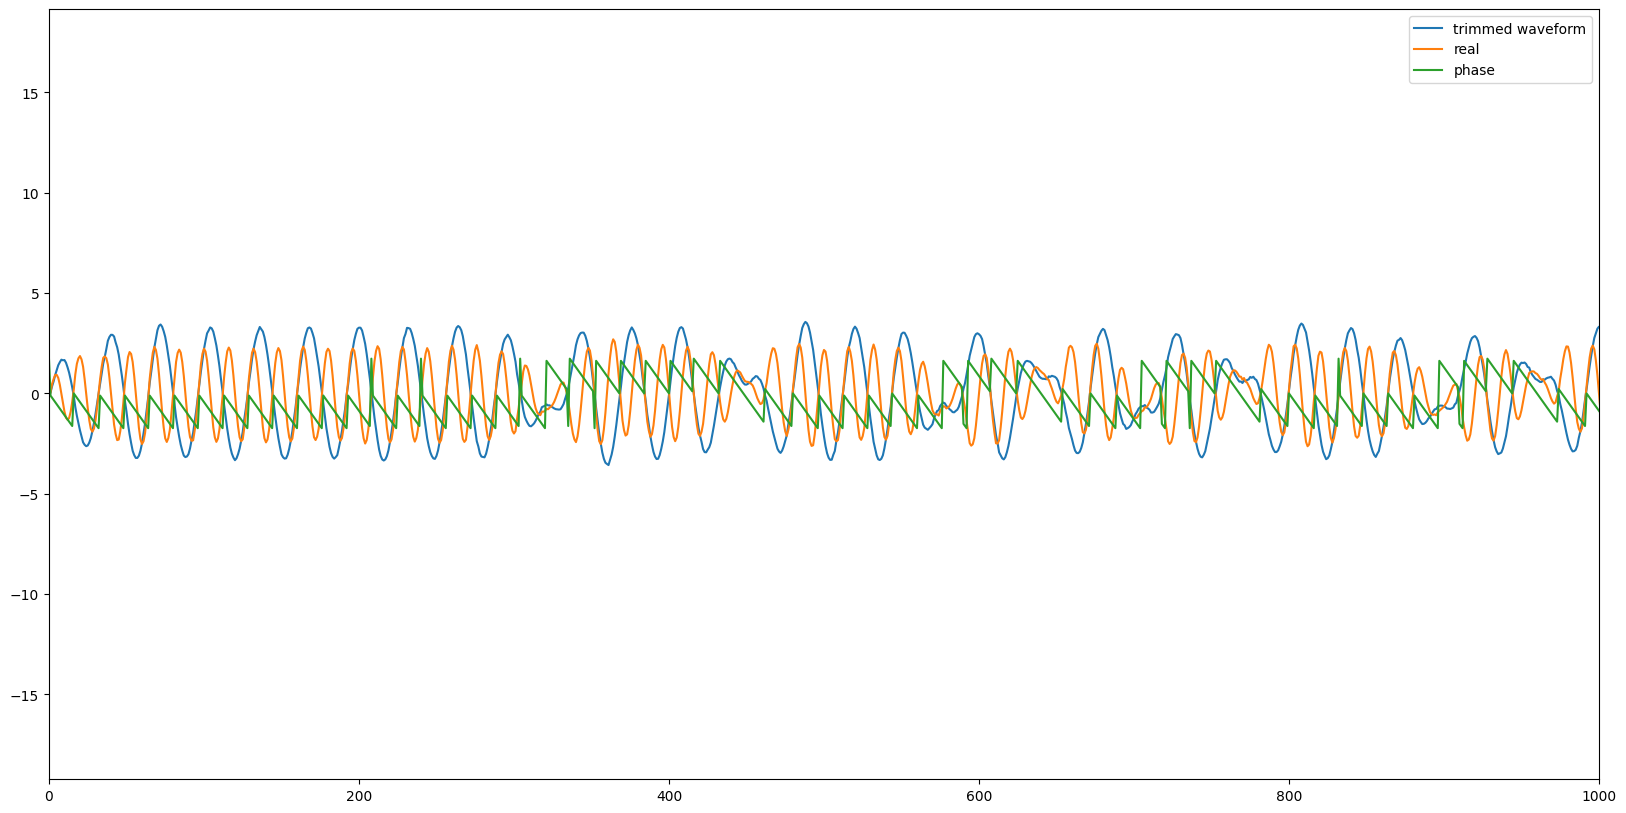

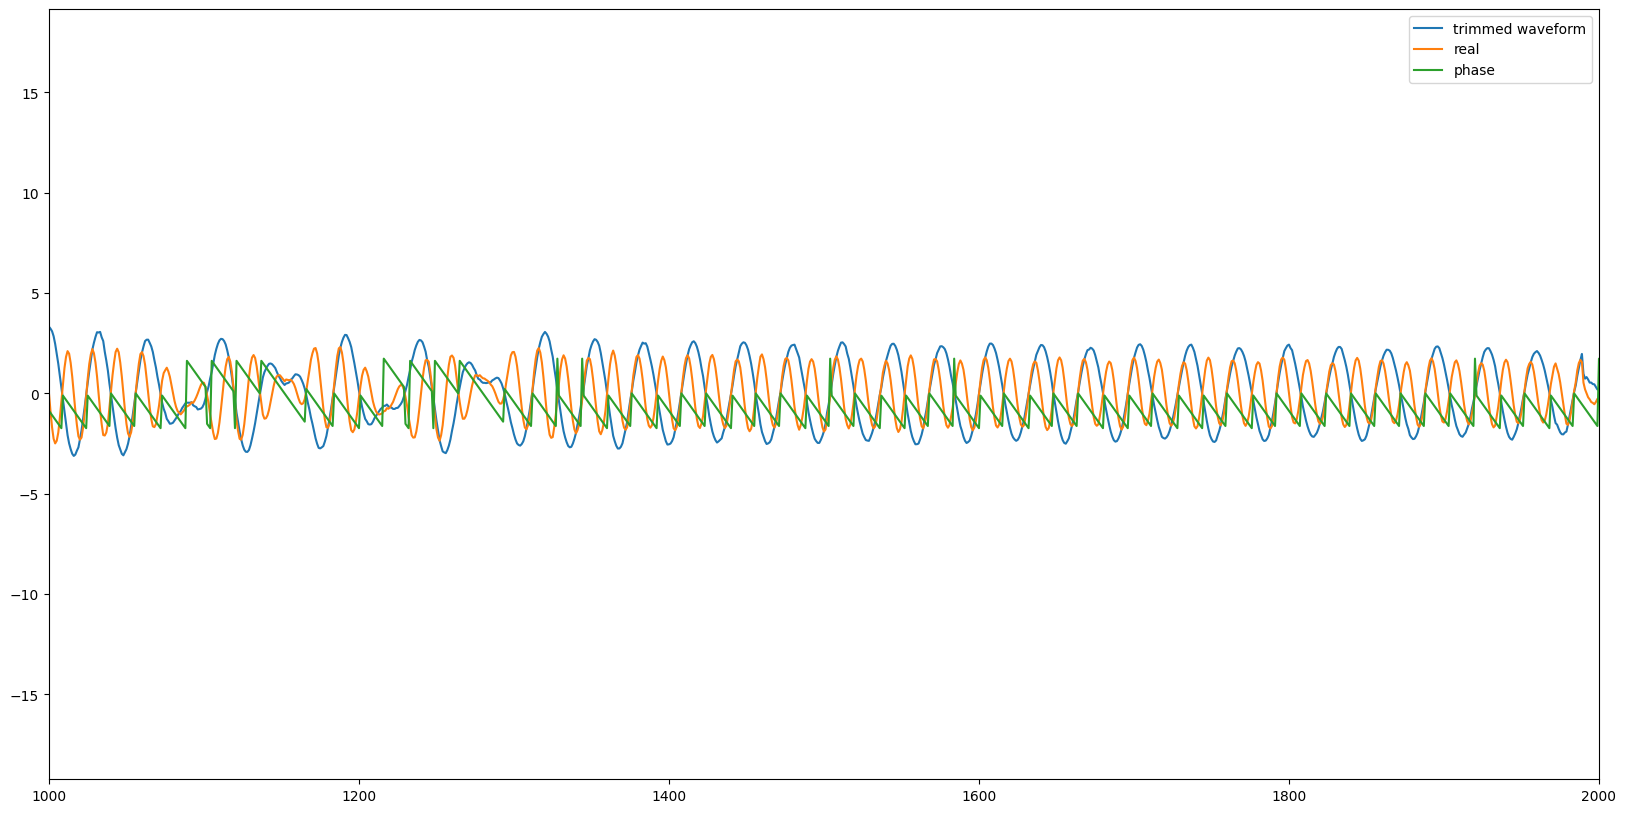

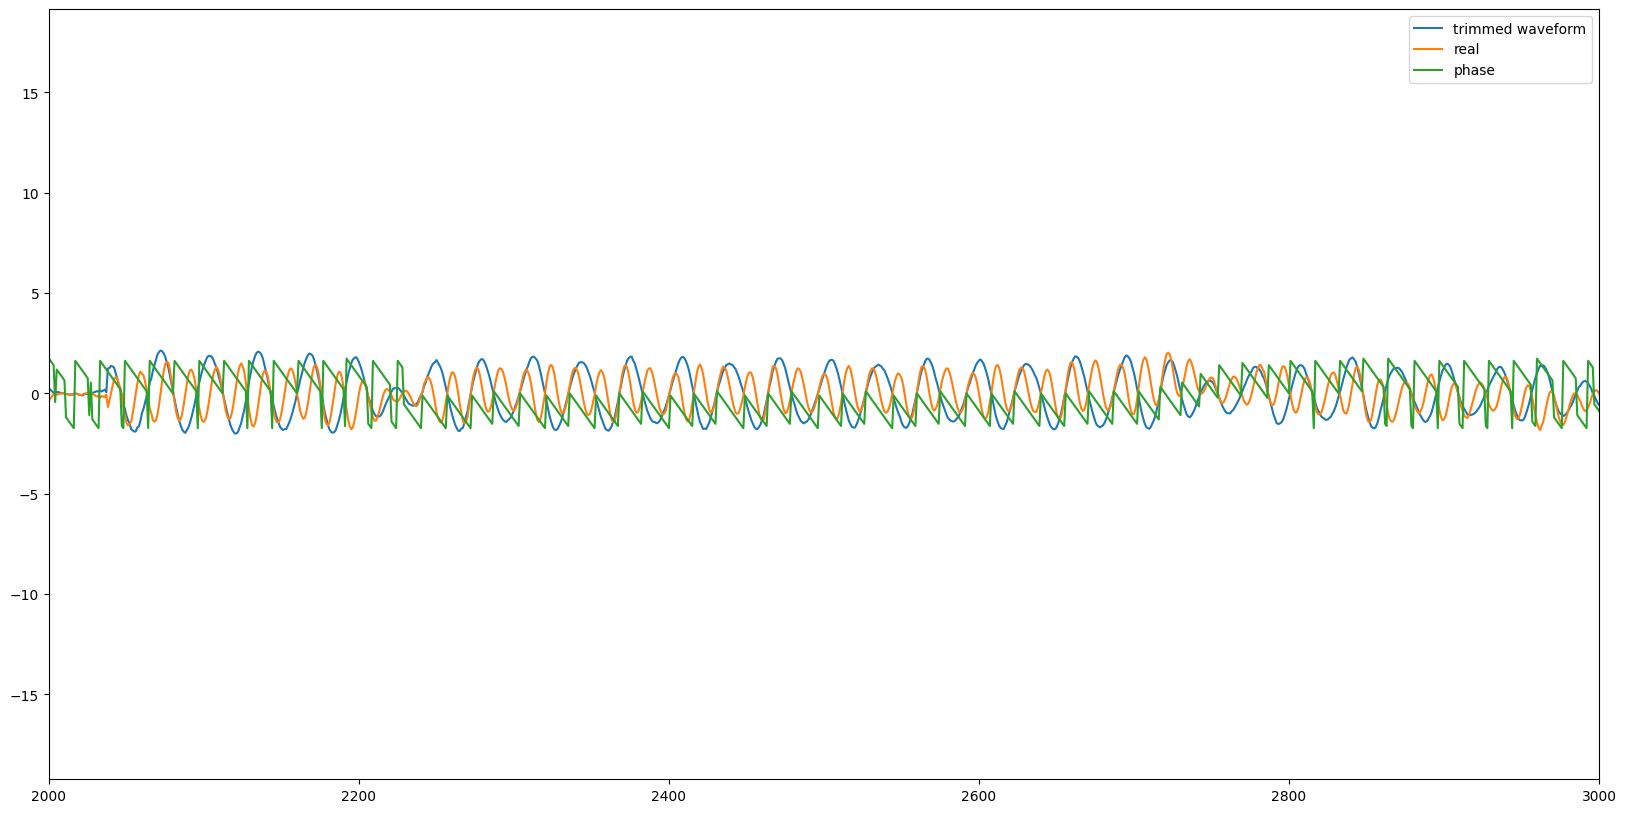

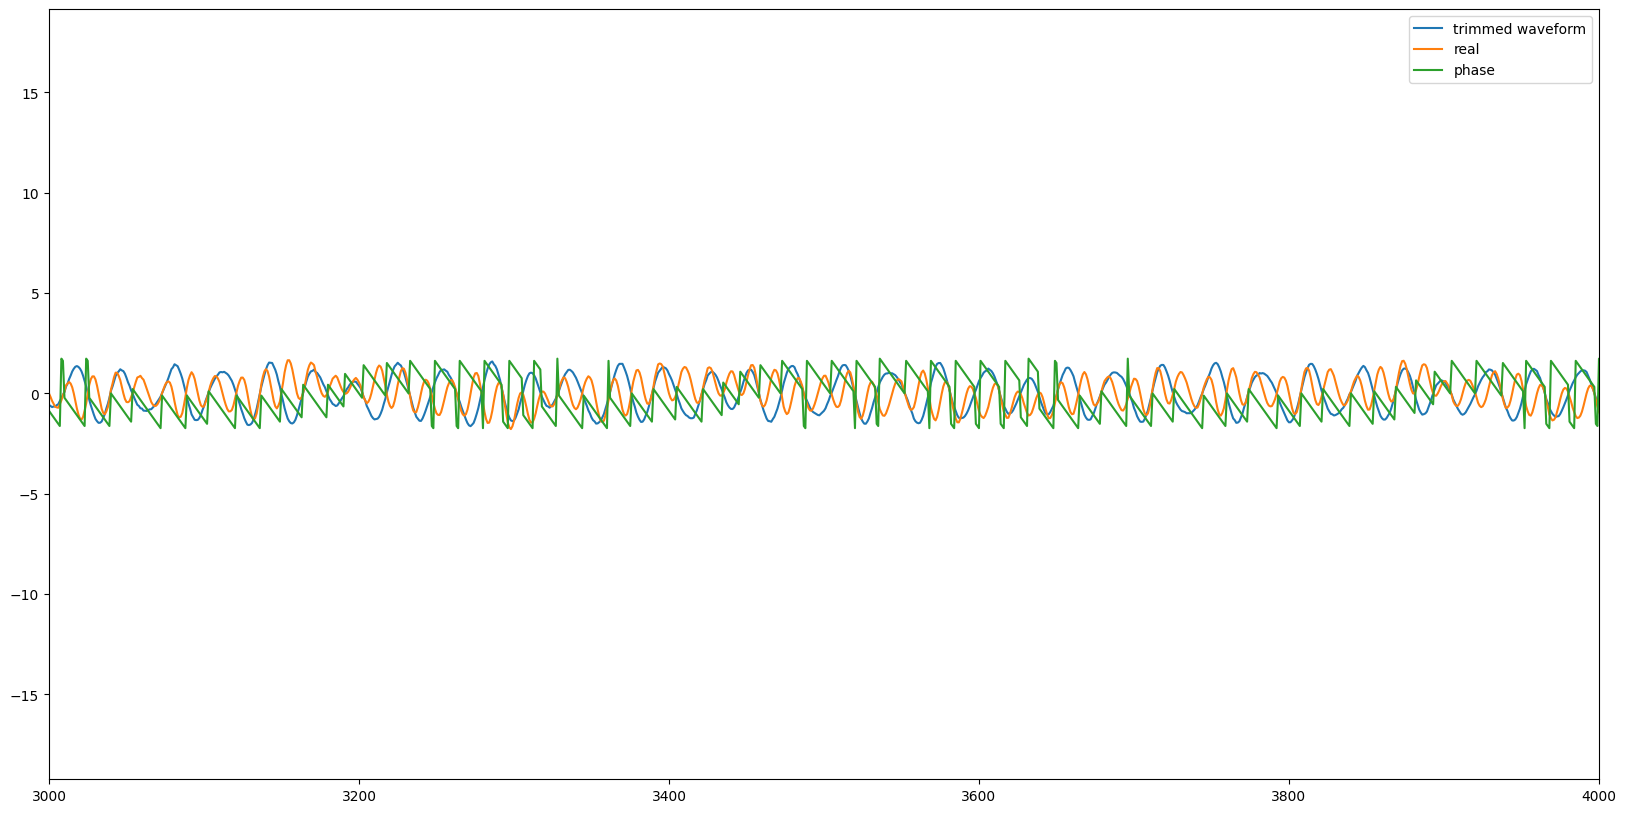

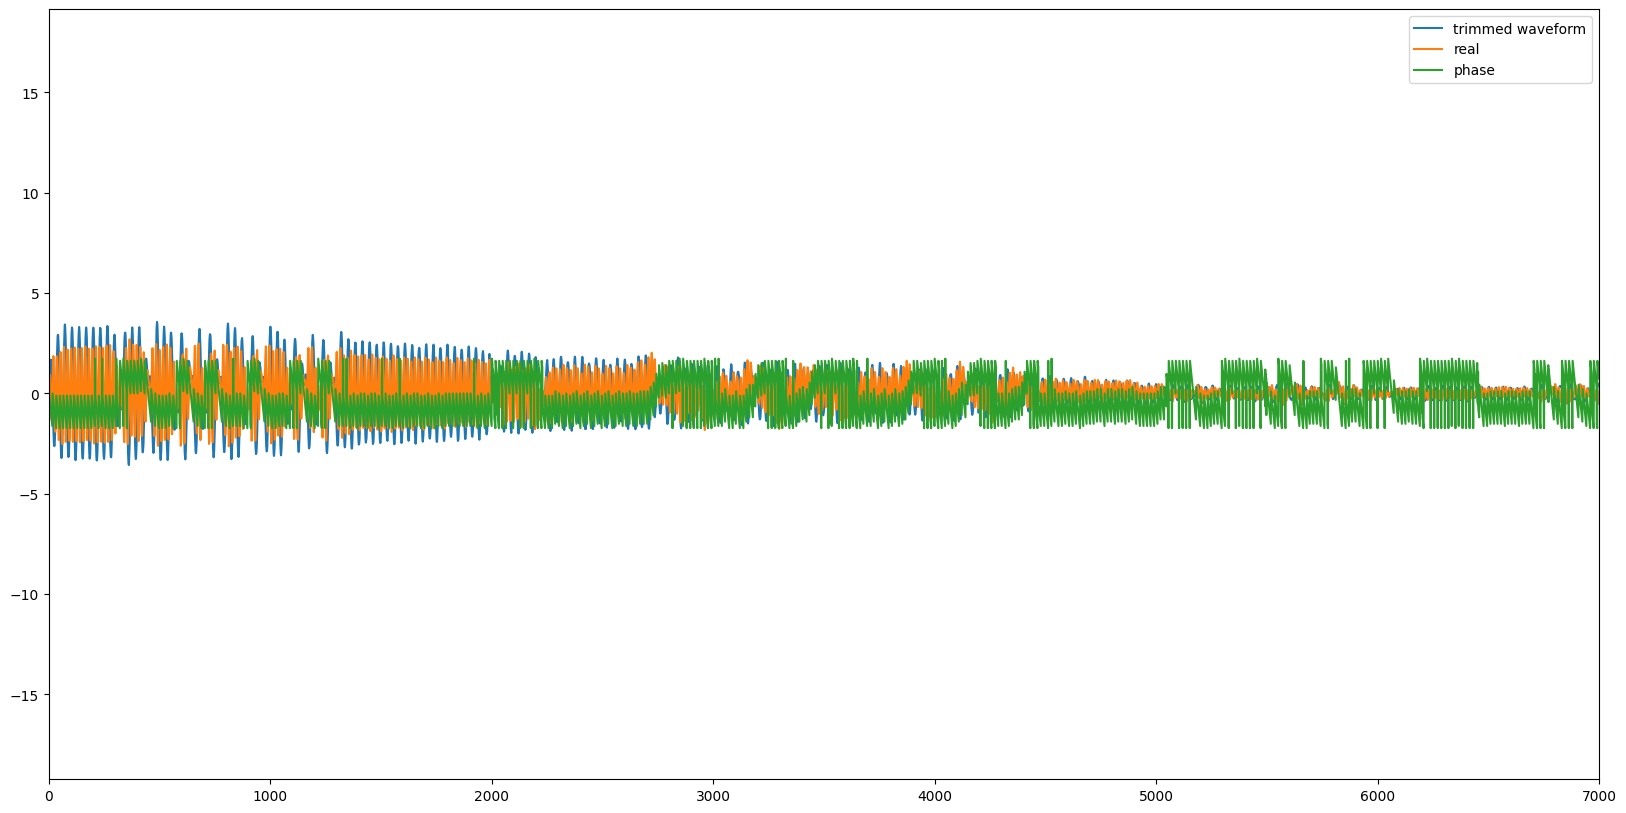

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def plot_baseband(
    trimmed_waveform,
    phase,
    real,
    start: int = 0,
    end: int = 1000,
    save: bool = True,
):
    normalized_trimmed_waveform = trimmed_waveform / np.std(trimmed_waveform)
    normalized_phase = phase / np.std(phase)
    normalized_real = real / np.std(real)
    # normalized_phase = phase
    # normalized_real = real
    plt.figure(figsize=(20, 10))
    plt.plot(normalized_trimmed_waveform[::10], label="trimmed waveform")
    plt.plot(normalized_real[::10], label="real")
    plt.plot(normalized_phase[::10], label="phase")
    plt.xlim([start, end])
    plt.legend()
    if save:
        plt.savefig(f"../../output/{start}_{end}.png")


data = np.load("../../output/drift_data.npz")
trimmed_waveform = data["trimmed_waveform"]
sample_rate = data["sample_rate"]
frequency = data["frequency"]
t = np.arange(0, trimmed_waveform.shape[0], dtype=float) / sample_rate
multiplication = trimmed_waveform * np.exp(-1j * 2 * np.pi * frequency * t)
real = np.real(multiplication)
phase = np.angle(multiplication)
print(f"min:{min(real)}\nmax:{max(real)}")

plot_baseband(trimmed_waveform, phase, real, 0, 1000)
plot_baseband(trimmed_waveform, phase, real, 1000, 2000)
plot_baseband(trimmed_waveform, phase, real, 2000, 3000)
plot_baseband(trimmed_waveform, phase, real, 3000, 4000)
plot_baseband(trimmed_waveform, phase, real, 0, 7000)

-3.1415898579921633
3.1415872441335386


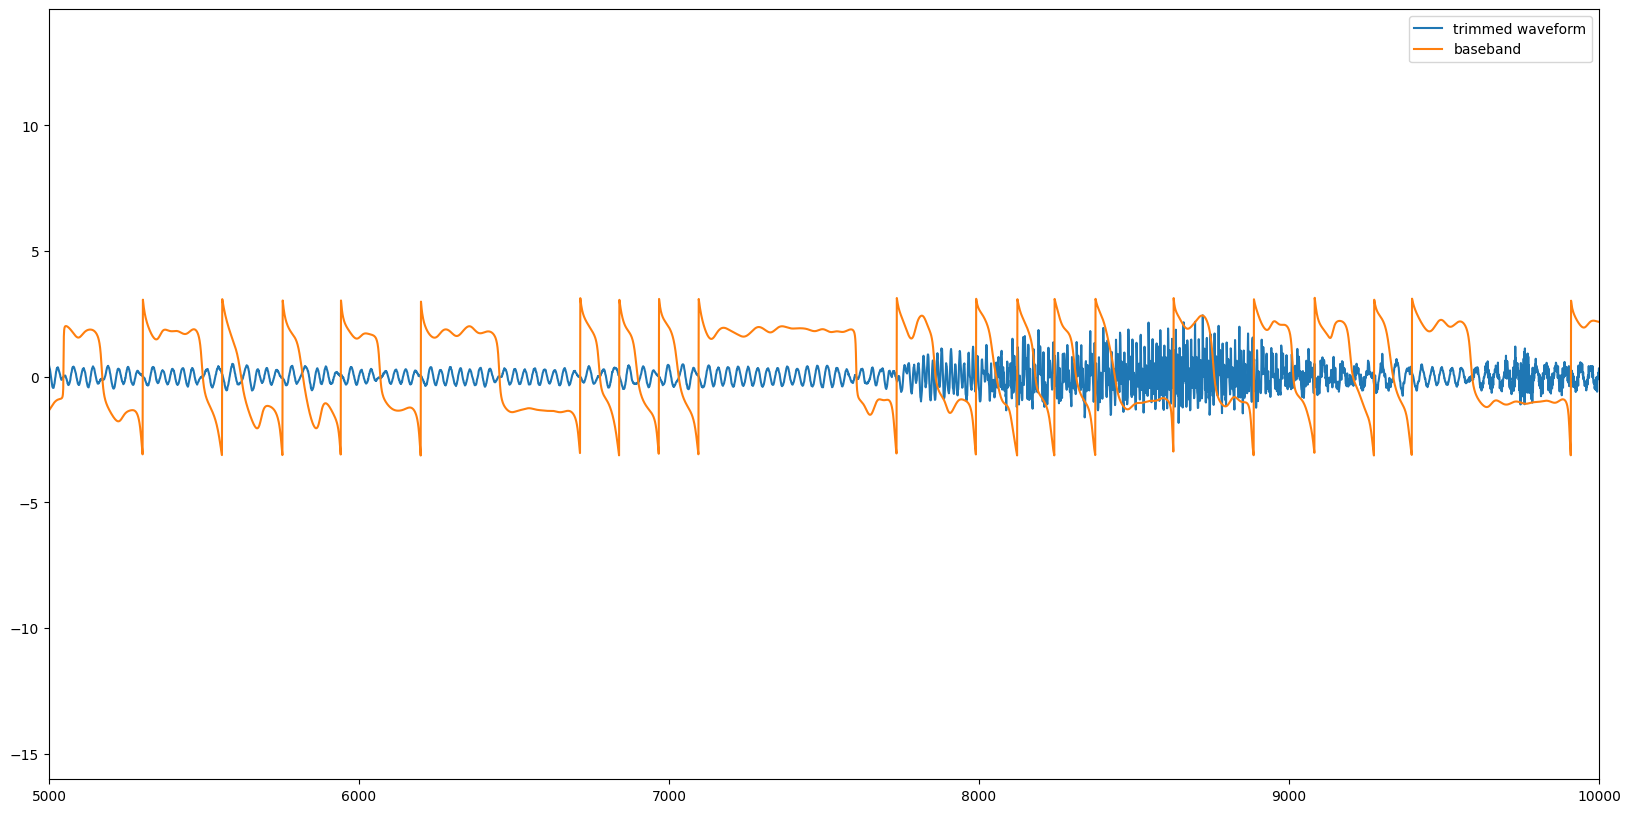

In [11]:
from scipy import signal
import numpy as np


def low_pass_filter(
    wave,
    sample_rate: int,
    cutoff_frequency: float = 100.0,
    order: int = 5,
):
    # Calculate normalized cutoff frequency (Wn = 2 * fc / fs)
    Wn = cutoff_frequency / (sample_rate / 2)
    b, a = signal.butter(order, Wn, btype="low")  # type: ignore
    baseband = signal.filtfilt(b, a, wave)
    return baseband


def plot_baseband(
    trimmed_waveform,
    baseband,
    start: int = 0,
    end: int = 1000,
    save: bool = True,
):
    normalized_trimmed_waveform = trimmed_waveform / np.std(trimmed_waveform)
    # normalized_phase = phase
    # normalized_real = real
    plt.figure(figsize=(20, 10))
    plt.plot(normalized_trimmed_waveform[::10], label="trimmed waveform")
    plt.plot(baseband[::10], label="baseband")
    plt.xlim([start, end])
    plt.legend()
    if save:
        plt.savefig(f"../../output/{start}_{end}.png")


time_vector = np.arange(len(trimmed_waveform)) / sample_rate
osc = np.exp(-1j * 2 * np.pi * time_vector * frequency)
baseband = osc * trimmed_waveform
baseband = low_pass_filter(baseband, sample_rate)
phase = np.angle(baseband)
print(min(phase))
print(max(phase))
start = 5000
end = start + 5000
plot_baseband(trimmed_waveform, phase, start, end, save=False)